# 03 — Детекция: DBSCAN + Louvain

Запускаем оба метода, сравниваем их по отдельности и в комбо.

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
sns.set_theme(style='whitegrid')

from src.detection import detect, build_graph, run_louvain

feats = pd.read_csv('../data/processed/features.csv', index_col='user_id')
actions = pd.read_csv('../data/raw/actions.csv', parse_dates=['ts'])
follows = pd.read_csv('../data/raw/follows.csv', parse_dates=['ts'])


In [2]:
predictions = detect(feats, follows, actions)
predictions[['is_bot','bot_candidate','in_dbscan_cluster','in_suspicious_community']].head()


[detect] DBSCAN по фичам...
[detect] Строю граф (подписки + общие /24 подсети)...


           узлов: 2160, рёбер: 32522
[detect] Louvain community detection...


[detect] Подозрительных Louvain-сообществ: 5
[detect] Кандидатов в боты: 187 из 2160


,is_bot,bot_candidate,in_dbscan_cluster,in_suspicious_community
user_id,,,,
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0


## DBSCAN: размеры кластеров

In [3]:
dbs = predictions['dbscan_label'].value_counts().sort_index()
dbs.head(20)


dbscan_label
-1      73
 0    1493
 1     184
 2     254
 3      27
 4     116
 5      13
Name: count, dtype: int64

Гигантский кластер (label со многими тысячами) — это нормальная масса; маленькие кластеры (10..100 человек) — кандидаты в фермы. Метка -1 означает шум.

## Louvain: распределение размеров сообществ

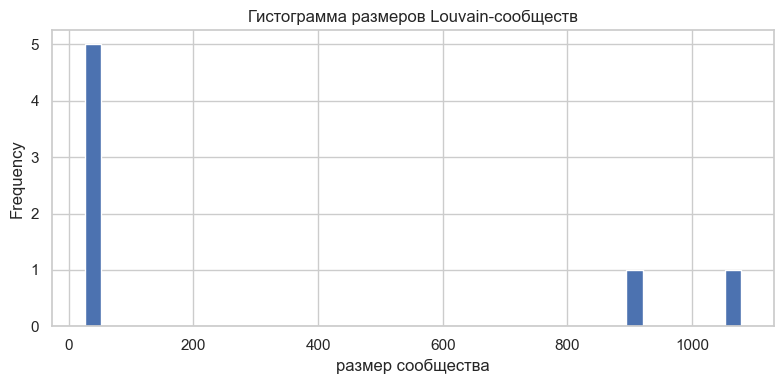

Топ-10 крупнейших сообществ:
louvain_community
5    1079
6     921
1      47
3      31
2      30
0      26
4      26
Name: count, dtype: int64

Подозрительные сообщества (in_suspicious_community=1):
                   size  bots  bot_share  avg_mutual  avg_dup
louvain_community                                            
0                    26    26        1.0    0.689604      1.0
1                    47    47        1.0    0.714020      1.0
2                    30    30        1.0    0.732442      1.0
3                    31    31        1.0    0.720729      1.0
4                    26    26        1.0    0.731880      1.0


In [4]:
louv = predictions['louvain_community'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
louv.plot.hist(bins=40, ax=ax)
ax.set_xlabel('размер сообщества')
ax.set_title('Гистограмма размеров Louvain-сообществ')
plt.tight_layout(); plt.show()

print('Топ-10 крупнейших сообществ:')
print(louv.head(10))

print('\nПодозрительные сообщества (in_suspicious_community=1):')
susp = predictions[predictions.in_suspicious_community==1]
print(susp.groupby('louvain_community').agg(
    size=('louvain_community','size'),
    bots=('is_bot','sum'),
    bot_share=('is_bot','mean'),
    avg_mutual=('mutual_follow_share','mean'),
    avg_dup=('duplicate_text_share','mean'),
))


## Визуализация графа: подграф вокруг подозрительных сообществ

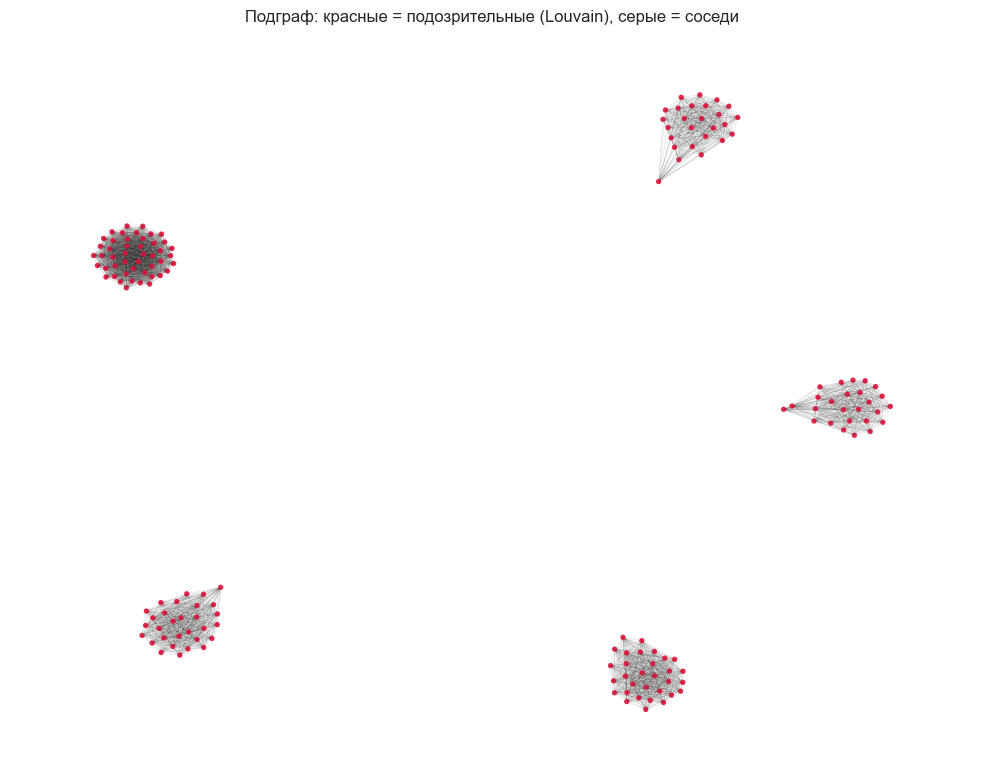

In [5]:
graph = build_graph(follows, actions)
susp_nodes = set(predictions[predictions.in_suspicious_community==1].index)
# для читаемости берём только узлы из подозрительных и небольшой 1-hop кружок
subgraph_nodes = set(susp_nodes)
for n in list(susp_nodes)[:200]:
    subgraph_nodes.update(list(graph.neighbors(n))[:5])
subg = graph.subgraph(subgraph_nodes)

node_color = ['crimson' if n in susp_nodes else 'lightgray' for n in subg.nodes]
fig, ax = plt.subplots(figsize=(10,8))
pos = nx.spring_layout(subg, seed=42, k=0.4)
nx.draw_networkx_nodes(subg, pos, node_size=8, node_color=node_color, alpha=0.85, ax=ax)
nx.draw_networkx_edges(subg, pos, alpha=0.15, width=0.4, ax=ax)
ax.set_title('Подграф: красные = подозрительные (Louvain), серые = соседи')
ax.axis('off')
plt.tight_layout(); plt.show()


Видно несколько плотных красных сгустков — это и есть фермы. Серые точки — нормальные юзеры, попавшие в радиус по случайным подпискам.

Дальше: оценка качества в `04_report.ipynb`.